# Verification of Hyperparameter Search Setup

This notebook runs the verification step of the hyperparameter search to ensure that the default parameters produce reasonable results.

In [20]:
%load_ext autoreload
%autoreload 2
import numpy as np
import logging
import sys
from pathlib import Path
import torch


import matplotlib.pyplot as plt
import diffmeshopt.opt2d.hyperparameter_search as hps
from diffmeshopt.opt2d.hyperparameter_search import ExperimentRunner

# Configure logging to stdout
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s - %(levelname)s - %(message)s",
    handlers=[logging.StreamHandler(sys.stdout)],
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# Define paths
dataset_path = "../data/2d_training_data_perturbations.pkl"  # Adjust if needed
output_dir = "../output/verification_test"
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Using device: {device}")

Using device: cuda


In [3]:
# Initialize Runner
runner = ExperimentRunner(dataset_path, output_dir, device=device)

2026-02-05 07:09:07,411 - INFO - Loading dataset from ../data/2d_training_data_perturbations.pkl


In [12]:
# Run Verification
success = runner.verify_run()

if success:
    print("Verification run SUCCESSFUL.")
else:
    print("Verification run FAILED.")

2026-02-05 01:38:36,543 - INFO - Starting verification run...
2026-02-05 01:38:36,546 - INFO - Verifying on case: original
2026-02-05 01:38:36,547 - INFO - Running case: original
2026-02-05 01:38:36,550 - INFO - Parameters: {"trial_id": "verify", "refiner": "vertex", "template": "fixed", "symmetric": true, "reg_mode": "static", "num_cp": 50, "rbf_sigma": 1.0, "smoothness_window_size": 3, "w_laplacian": 0.0, "w_edge": 0.0, "w_normal": 2.0, "w_tangential": 5.0, "w_shape": 1.0, "w_anchor": 0.0, "w_smooth_param": 0.0}
2026-02-05 01:38:36,562 - INFO - Used params: ['refiner', 'reg_mode', 'smoothness_window_size', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_shape', 'w_smooth_param', 'w_tangential']
2026-02-05 01:38:36,565 - INFO - Unused params: ['num_cp', 'rbf_sigma']
2026-02-05 01:38:36,566 - INFO - Creating template model: fixed
2026-02-05 01:38:36,569 - INFO - Initializing ContourLoss
2026-02-05 01:38:36,579 - INFO - Output directory set to: .

Verification run FAILED.


In [13]:
runner.dataset

{'original': {'image': array([[ 2.297275  ,  0.91952544, -2.0356364 , ...,  0.21159673,
          -0.23363565,  0.15315445],
         [ 1.8387552 ,  1.2001783 , -1.3369218 , ..., -0.14449075,
          -0.6242144 , -0.86408305],
         [ 1.8006349 ,  1.7902691 , -0.05409441, ..., -0.26369014,
          -0.6464207 , -1.4863769 ],
         ...,
         [ 2.5699203 ,  0.20695859, -1.7928543 , ...,  0.09133457,
           0.27496427, -0.88100076],
         [ 3.1548681 ,  0.90663016, -1.2301186 , ..., -0.01659781,
           0.1031739 , -0.24120745],
         [ 2.0510318 ,  1.1162981 , -0.46858796, ..., -0.61368215,
          -0.14164342,  0.49266273]], shape=(413, 409), dtype=float32),
  'contour': array([[362.5, 223. ],
         [362.5, 222. ],
         [362.5, 221. ],
         ...,
         [361.5, 224. ],
         [362. , 223.5],
         [362.5, 223. ]], shape=(1241, 2)),
  'gt': array([], shape=(0, 2), dtype=float64),
  'offset': 0,
  'perturb': 0.0},
 'shrink_5_perturb_3': {'image

In [14]:
### First test is without the tangential and normal laplacian

In [ ]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "global",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 50.0,
    "w_edge": 10.0,
    "w_normal": 0.0,
    "w_tangential": 0.0,
    # "w_normal": 50.0,
    # "w_tangential": 100.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 0.0,
}


In [16]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-02-05 01:40:05,955 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_shape', 'w_smooth_param', 'w_tangential']
2026-02-05 01:40:05,960 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma']


In [17]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [18]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-02-05 01:42:37,136 - INFO - Creating template model: global


In [19]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [20]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-02-05 01:42:54,797 - INFO - Initializing ContourLoss


In [21]:
refiner.to(device)

ContourRefiner(
  (template_model): GlobalOptimizableTemplateModel()
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [22]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [23]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-02-05 01:43:34,120 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-02-05_01-43-34
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [24]:
trainer.fit(2000)

2026-02-05 01:43:42,819 - INFO - Starting fit for 2000 steps.
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/verification_test/trials/verification/2026-02-05_01-43-34 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 0: 100%|#| 2000/2000 [00:41<00:00, 48.73it/s, v_num=1.0, total_loss=0.948]

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-02-05 01:44:23,929 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-02-05_01-43-34/final.pkl


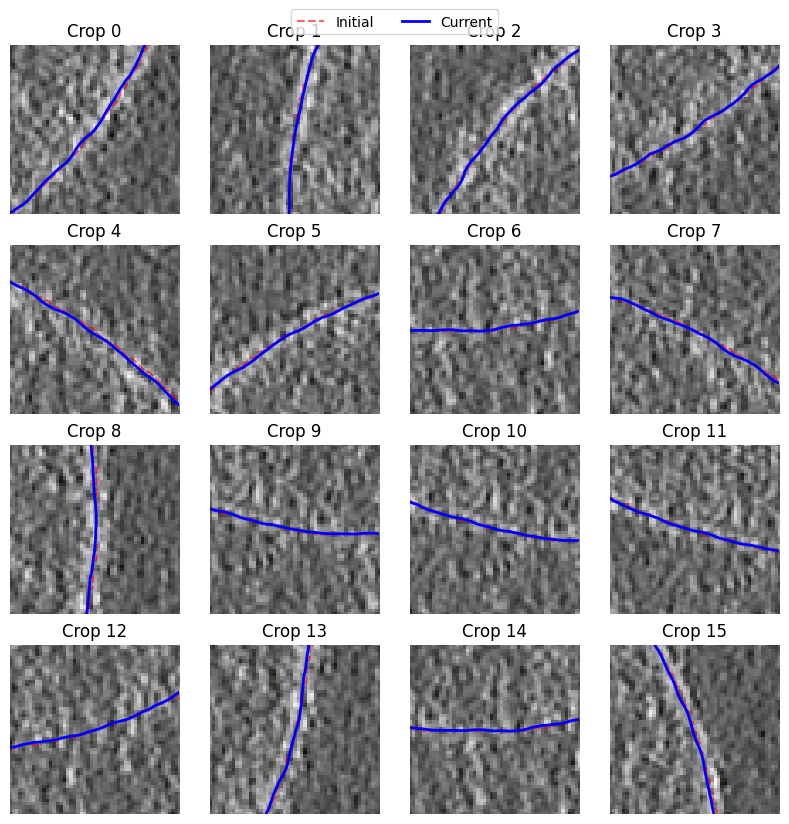

In [25]:
trainer.plot_image()

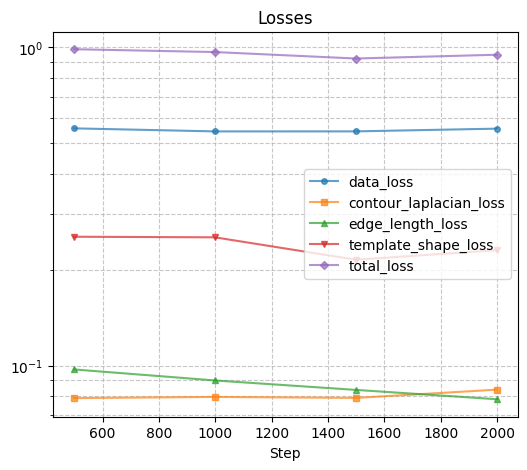

In [26]:
trainer.plot_metrics()

In [28]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"].item()

AttributeError: 'float' object has no attribute 'item'

In [29]:
metrics["mean_dist"]

0.4205182194709778

In [30]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor(3.6611, grad_fn=<MulBackward0>),
 'sigma1': tensor(1.4373, grad_fn=<ExpBackward0>),
 'sigma2': tensor(1.4373, grad_fn=<ExpBackward0>),
 'amp1': tensor(1.),
 'amp2': tensor(1.)}

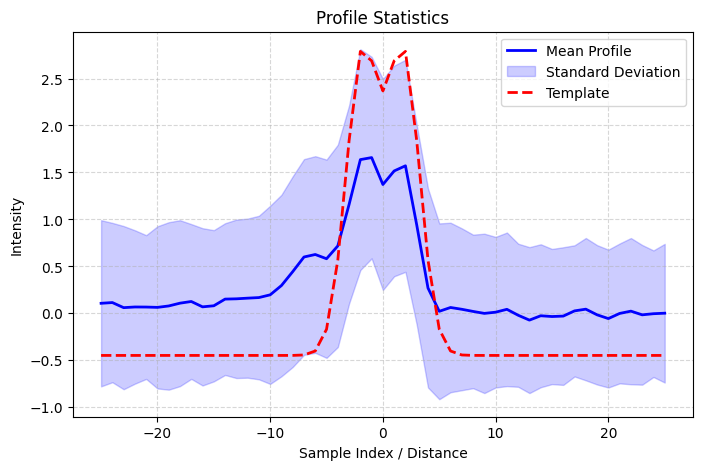

In [32]:
refiner.visualize_profile_statistics(image_t.cpu())

In [ ]:
## Verifying a per-vertex template with laplacian and edge-based smoothing.

In [4]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 50.0,
    "w_edge": 10.0,
    "w_normal": 0.0,
    "w_tangential": 0.0,
    # "w_normal": 50.0,
    # "w_tangential": 100.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "min_peak_ratio": 2.0,
}


In [5]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-02-05 07:09:51,023 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_shape', 'w_smooth_param', 'w_tangential']
2026-02-05 07:09:51,026 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma']


In [36]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [6]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-02-05 07:11:10,624 - INFO - Creating template model: per_point


In [7]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [8]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-02-05 07:11:27,818 - INFO - Initializing ContourLoss


In [9]:
refiner.to(device)

ContourRefiner(
  (template_model): PerPointTemplateModel(
    (laplacian_loss_fn): LaplacianSmoothingLoss()
  )
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [10]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [11]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-02-05 07:11:47,459 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-02-05_07-11-47
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [12]:
trainer.fit(2000)

2026-02-05 07:11:53,223 - INFO - Starting fit for 2000 steps.
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/verification_test/trials/verification/2026-02-05_07-11-47 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=191` in the `DataLoader` to improve performance.


Epoch 0: 100%|#| 2000/2000 [00:58<00:00, 34.01it/s, v_num=1.0, total_loss=0.902]

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-02-05 07:12:54,630 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-02-05_07-11-47/final.pkl


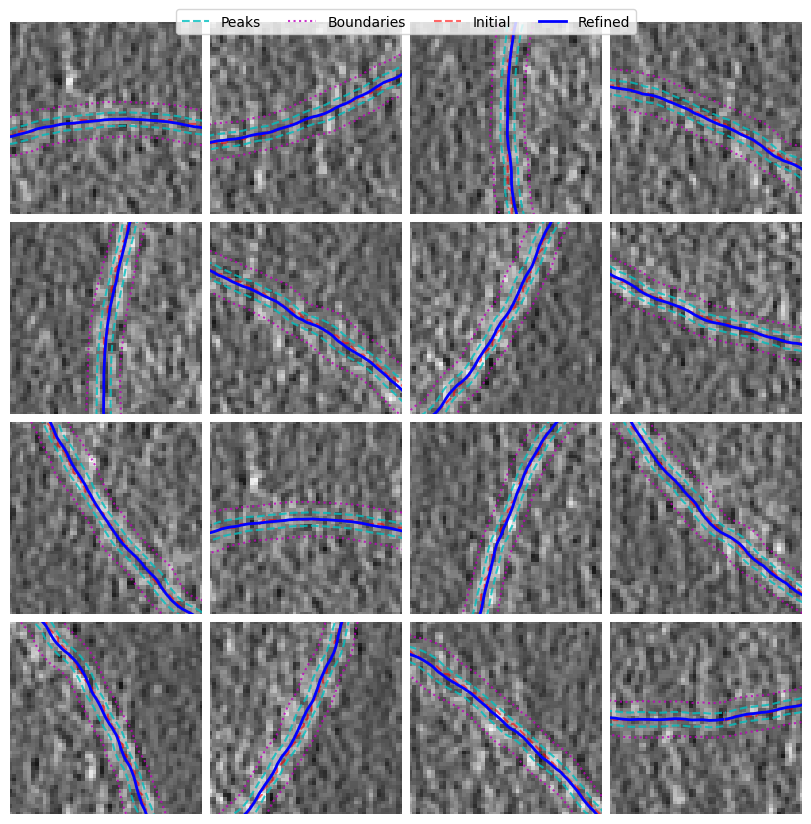

In [33]:
trainer.plot_image()

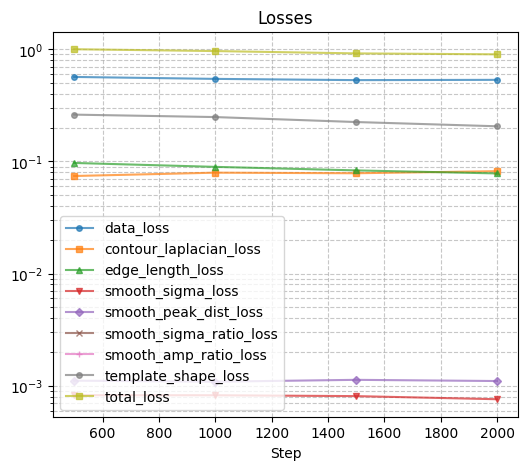

In [34]:
trainer.plot_metrics()

In [35]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]
chamfer

0.4229764938354492

In [36]:
metrics["mean_dist"]

0.4229764938354492

In [37]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor([3.5121, 3.5439, 3.5657,  ..., 3.4939, 3.4660, 3.4856],
        grad_fn=<MulBackward0>),
 'sigma1': tensor([1.3705, 1.3649, 1.3596,  ..., 1.3972, 1.3827, 1.3791],
        grad_fn=<ExpBackward0>),
 'sigma2': tensor([1.3705, 1.3649, 1.3596,  ..., 1.3972, 1.3827, 1.3791],
        grad_fn=<ExpBackward0>),
 'amp1': tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 'amp2': tensor([1., 1., 1.,  ..., 1., 1., 1.])}

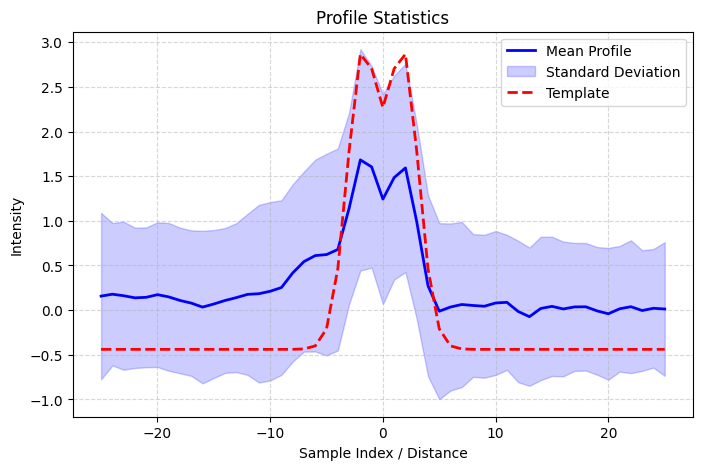

In [38]:
refiner.visualize_profile_statistics(image_t.cpu())

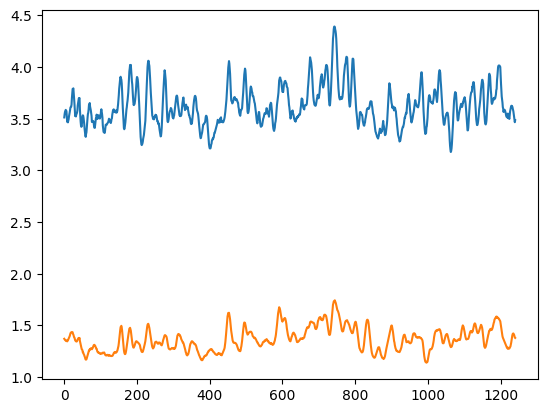

In [39]:
plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())

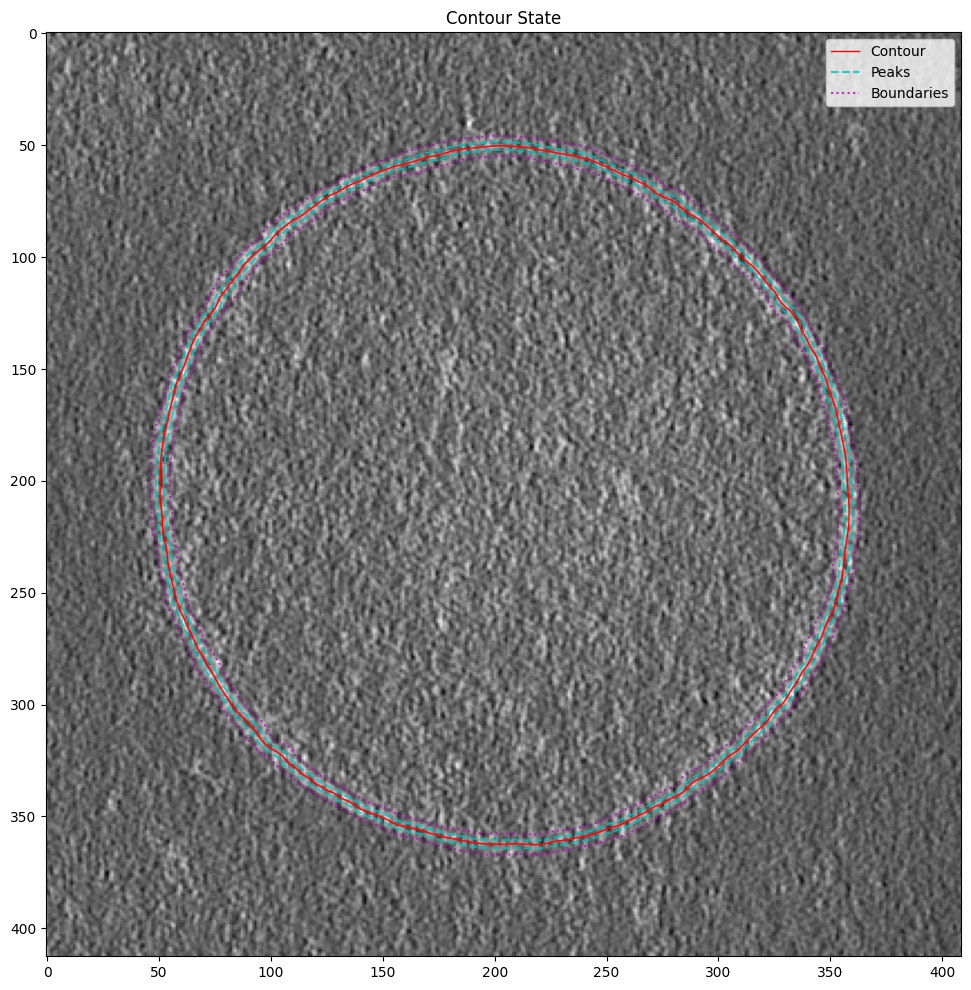

In [44]:
trainer.refiner.visualize_contour(image_t.detach())

In [45]:
## Verifying a per-vertex template with tangential and normal smoothing.

In [46]:
default_params = {
    "trial_id": "verify",
    "refiner": "vertex",
    "template": "per_point",
    "symmetric": True,
    "reg_mode": "static",
    "num_cp": 50,
    "rbf_sigma": 1.0,
    "w_laplacian": 0.0,
    "w_edge": 0.0,
    "w_normal": 50.0,
    "w_tangential": 5.0,
    "w_shape": 1.0,
    "w_anchor": 0.0,
    "w_smooth_param": 50.0,
    "min_peak_ratio": 2.0,
}


In [47]:
refiner_props, template_props, t_mode = runner._build_props(default_params)

2026-02-05 08:03:08,341 - INFO - Used params: ['refiner', 'reg_mode', 'symmetric', 'template', 'trial_id', 'w_anchor', 'w_edge', 'w_laplacian', 'w_normal', 'w_shape', 'w_smooth_param', 'w_tangential']
2026-02-05 08:03:08,346 - INFO - Unused params: ['min_peak_ratio', 'num_cp', 'rbf_sigma']


In [48]:
template_props

TemplateProps(sigma=0.75, peak_dist=4.0, min_peak_ratio=2.0, sigma_ratio=1.0, amp_ratio=1.0, symmetric=True, smoothness_window_size=3)

In [49]:
init_contour = runner.dataset["original"]["contour"]
image = runner.dataset["original"]["image"]
template_model = hps.TemplateModelFactory.create(
    t_mode,
    template_props,
    num_vertices=len(init_contour),
    image_shape=image.shape,
).to(runner.device)

2026-02-05 08:03:20,192 - INFO - Creating template model: per_point


In [50]:
# Prepare Tensors
image_t = torch.from_numpy(image).float().to(runner.device)
contour_t = torch.from_numpy(init_contour).float().to(runner.device)


In [51]:
refiner = hps.ContourRefiner(contour_t, refiner_props, template_model)

2026-02-05 08:03:36,531 - INFO - Initializing ContourLoss


In [52]:
refiner.to(device)

ContourRefiner(
  (template_model): PerPointTemplateModel(
    (laplacian_loss_fn): LaplacianSmoothingLoss()
  )
  (loss_fn): ContourLoss(
    (data_loss_fn): BiGaussianLoss()
    (laplacian_loss_fn): LaplacianSmoothingLoss()
    (edge_loss_fn): EdgeLengthConsistencyLoss()
    (spacing_loss_fn): LaplacianSmoothingLoss()
    (fairing_loss_fn): NormalConsistencyLoss()
    (shape_loss_fn): TemplateShapeLoss()
  )
)

In [53]:
run_dir = runner.output_dir / "trials" / f"verification"

config = hps.TrainerConfig(
    output_dir=run_dir,
    image=image,
    gt_contour=None,
    max_steps=2000,
    save_interval=2000,  # Only save at end
    log_interval=500,
    use_tensorboard=False,  # Disable TB to save IO
    save_images=True,
    enable_progress_bar=True,  # Disable progress bar for parallel runs
)

In [54]:
trainer = hps.OptimizationTrainer(refiner, config)

2026-02-05 08:04:29,943 - INFO - Output directory set to: ../output/verification_test/trials/verification/2026-02-05_08-04-29
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/fabric/plugins/environments/slurm.py:204: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /workspace/diffmeshopt/.pixi/envs/default/lib/python ...
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [55]:
trainer.fit(2000)

2026-02-05 08:04:41,248 - INFO - Starting fit for 2000 steps.
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/callbacks/model_checkpoint.py:881: Checkpoint directory /workspace/diffmeshopt/output/verification_test/trials/verification/2026-02-05_08-04-29 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/workspace/diffmeshopt/.pixi/envs/default/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=191` in the `DataLoader` to improve performance.


Epoch 0: 100%|#| 2000/2000 [00:56<00:00, 35.19it/s, v_num=1.0, total_loss=0.767]

`Trainer.fit` stopped: `max_steps=2000` reached.


2026-02-05 08:05:38,146 - INFO - Final state saved to ../output/verification_test/trials/verification/2026-02-05_08-04-29/final.pkl


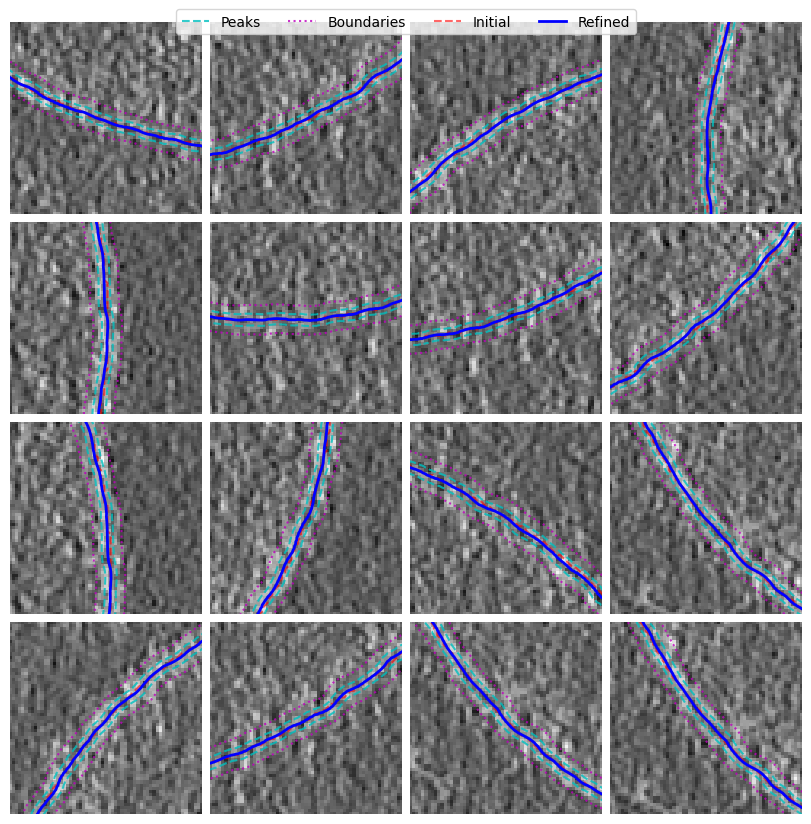

In [56]:
trainer.plot_image()

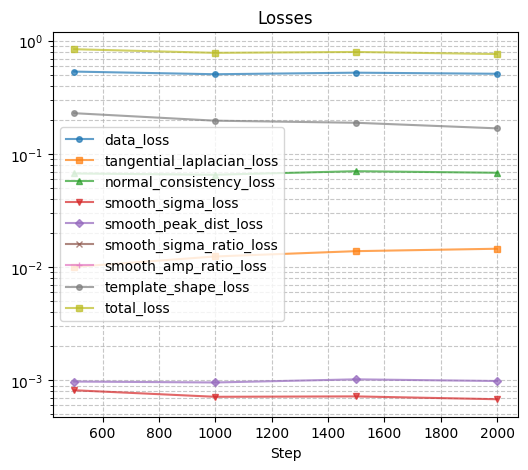

In [57]:
trainer.plot_metrics()

In [58]:
# Evaluate
final_contour = refiner.contour.detach().cpu().numpy()

# Check for NaNs or explosion
if np.isnan(final_contour).any() or np.max(np.abs(final_contour)) > max(image.shape) * 2:
    chamfer = np.inf


metrics = hps.compute_contour_metrics(refiner.contour, contour_t)
chamfer = metrics["mean_dist"]
chamfer

0.42464786767959595

In [60]:
template_params = trainer.refiner.template_model.get_params()
template_params


{'peak_dist': tensor([3.5129, 3.5440, 3.5549,  ..., 3.5449, 3.5315, 3.5213],
        grad_fn=<MulBackward0>),
 'sigma1': tensor([1.3489, 1.3455, 1.3346,  ..., 1.3622, 1.3609, 1.3565],
        grad_fn=<ExpBackward0>),
 'sigma2': tensor([1.3489, 1.3455, 1.3346,  ..., 1.3622, 1.3609, 1.3565],
        grad_fn=<ExpBackward0>),
 'amp1': tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 'amp2': tensor([1., 1., 1.,  ..., 1., 1., 1.])}

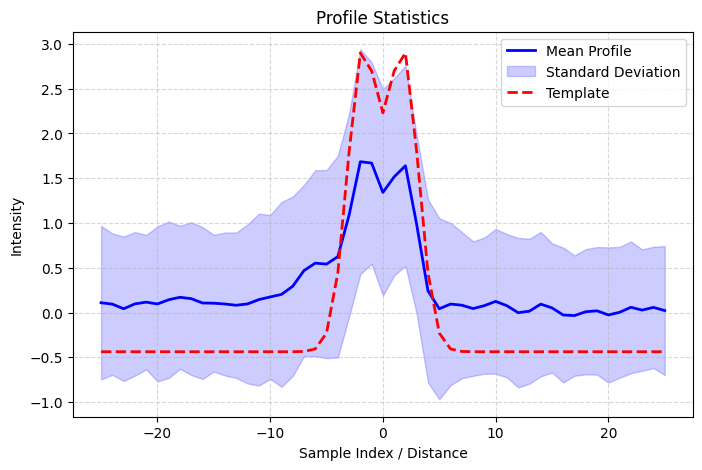

In [61]:
refiner.visualize_profile_statistics(image_t.cpu())

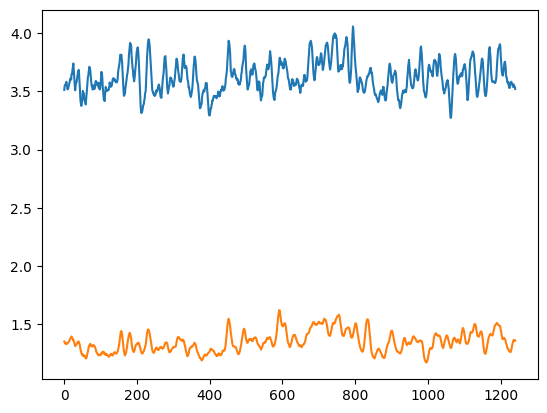

In [62]:
plt.plot(template_params["peak_dist"].detach().numpy())
plt.plot(template_params["sigma1"].detach().numpy())

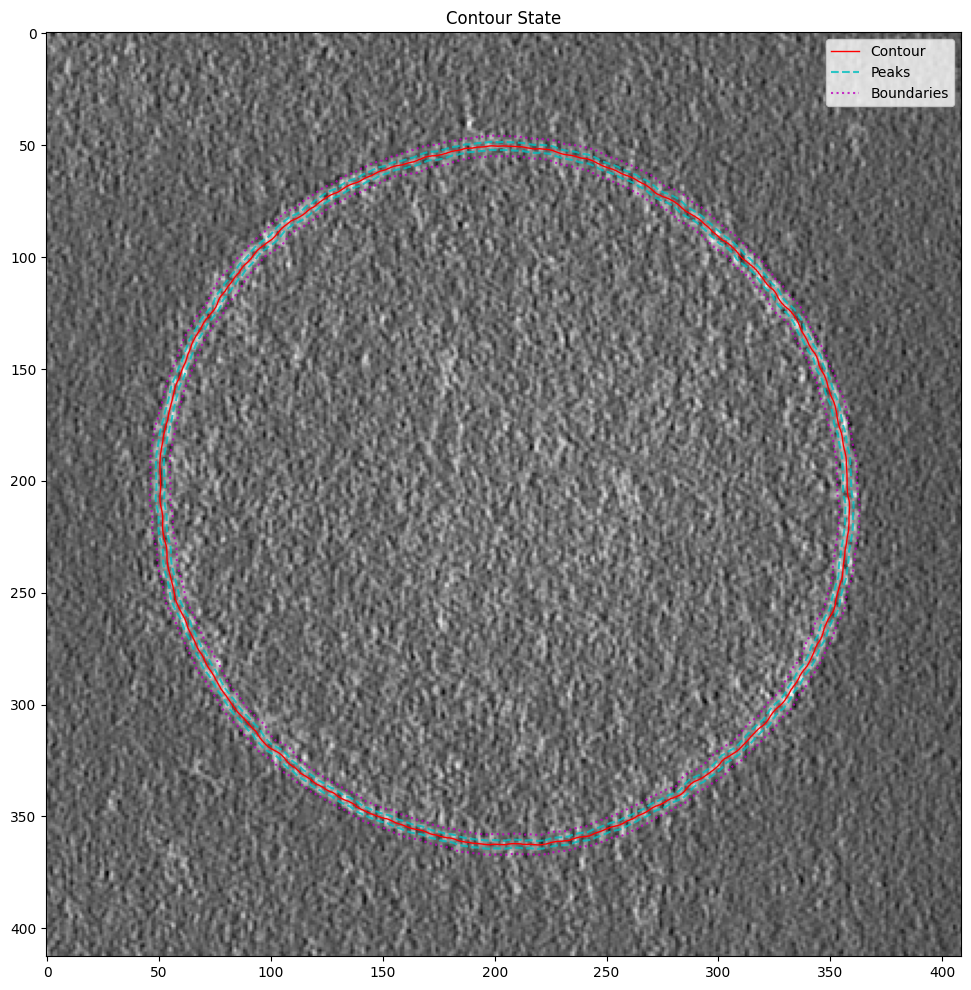

In [63]:
trainer.refiner.visualize_contour(image_t.detach())